In [ ]:
! git clone https://github.com/ds3001f25/trees_assignment.git

Question 1

1.1: Why is the Gini a good loss function for categorical target variables?

Answer: THe gini is an effective loss function because it measures the purity of a node post split. It is effective computationally and helps differentiate between poor and high quality splits.

1.2: Why do trees tend to overfit, and how can this tendency be constrained?

Answer: Decision trees often overfit because they continuously divide data into small regions. They capture unplanned noise opposed to general patterns. This tendency can be constrained by limiting the depth of the tree, pruning unnecessary splits, or applying regulation control to how complex the model is.

1.3: True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates.

Answer: False. Decision trees handle both categorical and numerical variables effectively. They are particularly well-suited for capturing non-linear relationships and complex interactions between features.

1.4: Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

Answer: Decision trees typically use binary splits because this approach simplifies the process of finding the optimal split, improves computational efficiency, and enhances the interpretability of the model.

1.5: What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

Answer: You can assess model performance by examining the tree's depth, the number of leaves, and the difference between training and validation accuracy. A very high training accuracy combined with a lower validation accuracy typically indicates overfitting, while low accuracy on both sets suggests underfitting.

In [92]:
# Question 3.1
# Importing data set: Corporate Ratings
from google.colab import files
uploaded = files.upload()

import pandas as pd
corporate_ratings_dataset = pd.read_csv('corporate_ratings.csv')
corporate_ratings_dataset.head()

Saving corporate_ratings.csv to corporate_ratings (2).csv


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


The corporate ratings dataset contained 2,029 observations and 31 variables.

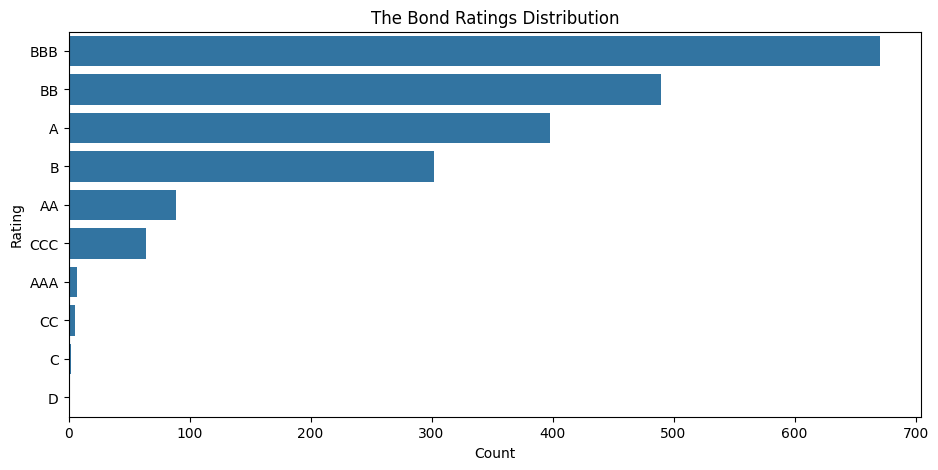

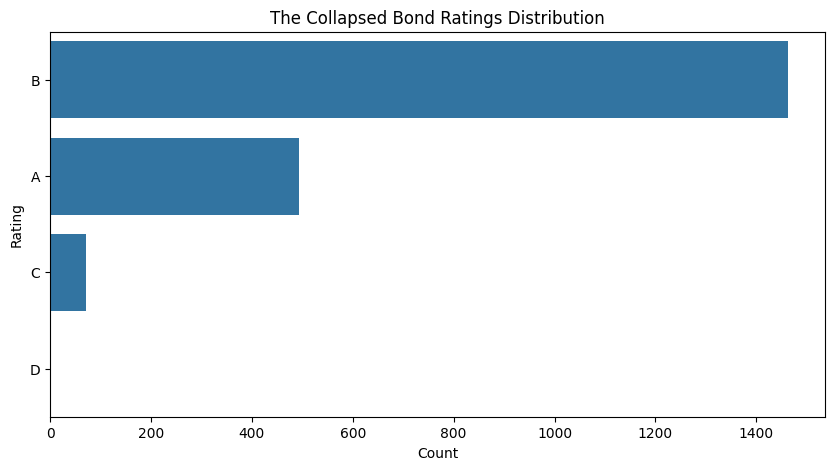

,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover,Collapsed_Rating
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655,A
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846,B
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510,B
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150,B
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790,B


In [97]:
# Question 3.2
# Histogram of ratings and collapsing the categories
df = corporate_ratings_dataset.copy()

# Histogram plot of corporate ratings
plt.figure(figsize=(11, 5))
sns.countplot(data=df, y='Rating', order=df['Rating'].value_counts().index)
plt.title('The Bond Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

# Collapsing the Ratings - I kept D without making any changes
rating_mapping = {
    'AAA': 'A', 'AA': 'A', 'A': 'A',
    'BBB': 'B', 'BB': 'B', 'B': 'B',
    'CCC': 'C', 'CC': 'C', 'C': 'C',
    'D': 'D'
}
df['Collapsed_Rating'] = df['Rating'].map(rating_mapping)

# Histogram of collapsed ratings
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='Collapsed_Rating', order=df['Collapsed_Rating'].value_counts().index)
plt.title('The Collapsed Bond Ratings Distribution')
plt.xlabel('Count')
plt.ylabel('Rating')
plt.show()

display(df.head())

In [100]:
# Question 3.3
# Preparing the features
exclude_features = ['Rating','Rating Agency Name', 'Date', 'Name', 'Symbol']

# Post feature selection and excluding certain columns and original rating
features = [col for col in df.columns if col not in exclude_features and col != 'Collapsed_Rating']

# Separation of target variable
x = df[features]
y = df['Collapsed_Rating']

# Dummy/one-hot-encoded representation of the sector column
X = pd.get_dummies(x, columns=['Sector'], dummy_na=False)

print("Dimensions of matrix X:", X.shape)
print("Dimensions of matrix y:", y.shape)
display(X.head())

Dimensions of matrix X: (2029, 37)
Dimensions of matrix y: (2029,)


,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,Sector_Consumer Durables,Sector_Consumer Non-Durables,Sector_Consumer Services,Sector_Energy,Sector_Finance,Sector_Health Care,Sector_Miscellaneous,Sector_Public Utilities,Sector_Technology,Sector_Transportation
0,0.945894,0.426395,0.099690,44.203245,0.037480,0.049351,0.176631,0.061510,0.041189,0.091514,...,True,False,False,False,False,False,False,False,False,False
1,1.033559,0.498234,0.203120,38.991156,0.044062,0.048857,0.175715,0.066546,0.053204,0.104800,...,True,False,False,False,False,False,False,False,False,False
2,0.963703,0.451505,0.122099,50.841385,0.032709,0.044334,0.170843,0.059783,0.032497,0.075955,...,True,False,False,False,False,False,False,False,False,False
3,1.019851,0.510402,0.176116,41.161738,0.020894,-0.012858,0.138059,0.042430,0.025690,-0.027015,...,True,False,False,False,False,False,False,False,False,False
4,0.957844,0.495432,0.141608,47.761126,0.042861,0.053770,0.177720,0.065354,0.046363,0.096945,...,True,False,False,False,False,False,False,False,False,False


In [95]:
# Questin 3.4: Train and evaluate model

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# Splitting the data into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Training Decision tree classifier
tree_clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
tree_clf.fit(X_train, y_train)

# Predictions on the test set
y_pred = tree_clf.predict(X_test)

# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(conf_matrix)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Confusion Matrix:
[[ 67  75   0   0]
 [ 71 363   6   0]
 [  0  22   4   0]
 [  1   0   0   0]]
Accuracy: 0.7126436781609196


The classifier shows a strong performance in predicting the dominant 'B' rating but shows notable confusion among the other classes, this leads to misclassifications and an accuracy of approximately 71%.

In [96]:
# Question 3.5
# Interpreting excluded features (withheld rating agency name from exclusion)
exclude_features = ['Rating', 'Collapsed_Rating', 'Date', 'Name', 'Symbol']

# select features and including agency name
features_with_agency = [col for col in df.columns if col not in exclude_features and col != 'Collapsed_Rating']

# Separating the target variable and keeping y the same
X_with_agency = df[features_with_agency]

# One-hot encode rating agency name and sector columns
X_with_agency = pd.get_dummies(X_with_agency, columns=['Rating Agency Name', 'Sector'], dummy_na=True)

print ("Matrix Shape X including the rating agency name'):", X_with_agency.shape)
print("Matrix Shape y:", y.shape)
display(X_with_agency.head())

# Splitting the data set into test and training sets
X_train_with_agency, X_test_with_agency, y_train_with_agency, y_test_with_agency = train_test_split(X_with_agency, y, test_size=0.3, random_state=42)

# Decision tree classifier training with min_samples_leaf constraint
tree_classifier_with_agency = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
tree_classifier_with_agency.fit(X_train_with_agency, y_train_with_agency)

# Predicting the test data set
y_pred_with_agency = tree_classifier_with_agency.predict(X_test_with_agency)

# Print confusion matrix
print("Confusion Matrix (Including Rating Agency Name):")
print(confusion_matrix(y_test_with_agency, y_pred_with_agency))

# Print accuracy
accuracy_with_agency = accuracy_score(y_test_with_agency, y_pred_with_agency)
print("Accuracy (Including Rating Agency Name):", accuracy_with_agency)

# Comparing the previous accuracy
print("Previous Accuracy (Excluding Rating Agency Name):", accuracy)

Matrix Shape X including the rating agency name'): (2029, 44)
Matrix Shape y: (2029,)


,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,netProfitMargin,pretaxProfitMargin,grossProfitMargin,operatingProfitMargin,returnOnAssets,returnOnCapitalEmployed,...,Sector_Consumer Non-Durables,Sector_Consumer Services,Sector_Energy,Sector_Finance,Sector_Health Care,Sector_Miscellaneous,Sector_Public Utilities,Sector_Technology,Sector_Transportation,Sector_nan
0,0.945894,0.426395,0.099690,44.203245,0.037480,0.049351,0.176631,0.061510,0.041189,0.091514,...,False,False,False,False,False,False,False,False,False,False
1,1.033559,0.498234,0.203120,38.991156,0.044062,0.048857,0.175715,0.066546,0.053204,0.104800,...,False,False,False,False,False,False,False,False,False,False
2,0.963703,0.451505,0.122099,50.841385,0.032709,0.044334,0.170843,0.059783,0.032497,0.075955,...,False,False,False,False,False,False,False,False,False,False
3,1.019851,0.510402,0.176116,41.161738,0.020894,-0.012858,0.138059,0.042430,0.025690,-0.027015,...,False,False,False,False,False,False,False,False,False,False
4,0.957844,0.495432,0.141608,47.761126,0.042861,0.053770,0.177720,0.065354,0.046363,0.096945,...,False,False,False,False,False,False,False,False,False,False


Confusion Matrix (Including Rating Agency Name):
[[ 91  51   0   0]
 [ 78 358   4   0]
 [  2  21   3   0]
 [  1   0   0   0]]
Accuracy (Including Rating Agency Name): 0.7422003284072249
Previous Accuracy (Excluding Rating Agency Name): 0.7126436781609196


The inclusion of the rating agency as a feature noticeably improved the model's performance. The overall accuracy increased from 71.3% to 74.2%, indicating that the model predicts bond ratings more accurately when it accounts for the agency providing the rating.

Changes in the confusion matrix reflect this improvement, as seen in the increase of correctly predicted 'A' ratings from 66 to 91. This shift suggests that incorporating the rating agency helps the model better differentiate between classes and reduce misclassifications.

Overall, these results indicate that the rating agency is a significant predictor of bond ratings, meaning that which agency provides the rating has a strong influence on the model's ability to correctly classify the outcome.